In [1]:
print("Feature Engineering")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('../data/processed/car_data_cleaned.csv')

print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:  {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")

Feature Engineering
Loaded: 291 rows x 8 columns

Column names:  ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']

Data types:
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
Car_Age            int64
dtype: object


In [2]:
print("\nPROBLEM 1 — TEXT DATA CONFUSES THE MODEL")
print("--------------------------------------------------")
print('Columns like "Petrol", "Diesel", and "CNG" are words.')
print("We must translate categories into mathematical form.")

print("\nPROBLEM 2 — SKEWED DATA DISTORTS LEARNING")
print("--------------------------------------------------")
print("Some numerical features are heavily right-skewed.")
print("For example, a few very expensive cars stretch the distribution.")
print("This can mislead the model and reduce prediction accuracy.")

print("\nPROBLEM 3 — FEATURES LIVE ON DIFFERENT SCALES")
print("--------------------------------------------------")
print("Car_Age may range from 1 to 20.")
print("Kms_Driven may range from 500 to 500,000.")
print("Without scaling, some models think larger numbers")
print("automatically mean greater importance.")

print("\nFeature Engineering is the transformation stage.")
print("It converts messy real-world data into clean mathematical signals")
print("that machine learning models can actually learn from.")

print("=== PROBLEM 1: Categorical columns ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Text columns: {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

print("\n=== PROBLEM 2: Skewness ===")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    skew = df[col].skew()
    flag = " ← SKEWED, needs transform" if abs(skew) > 1 else ""
    print(f"  {col:<20}: skew = {skew:+.2f}{flag}")

print("\n=== PROBLEM 3: Scale differences ===")
print(df[num_cols].describe().loc[['min','max']].round(1))


PROBLEM 1 — TEXT DATA CONFUSES THE MODEL
--------------------------------------------------
Columns like "Petrol", "Diesel", and "CNG" are words.
We must translate categories into mathematical form.

PROBLEM 2 — SKEWED DATA DISTORTS LEARNING
--------------------------------------------------
Some numerical features are heavily right-skewed.
For example, a few very expensive cars stretch the distribution.
This can mislead the model and reduce prediction accuracy.

PROBLEM 3 — FEATURES LIVE ON DIFFERENT SCALES
--------------------------------------------------
Car_Age may range from 1 to 20.
Kms_Driven may range from 500 to 500,000.
Without scaling, some models think larger numbers
automatically mean greater importance.

Feature Engineering is the transformation stage.
It converts messy real-world data into clean mathematical signals
that machine learning models can actually learn from.
=== PROBLEM 1: Categorical columns ===
Text columns: ['Fuel_Type', 'Seller_Type', 'Transmission']
  F

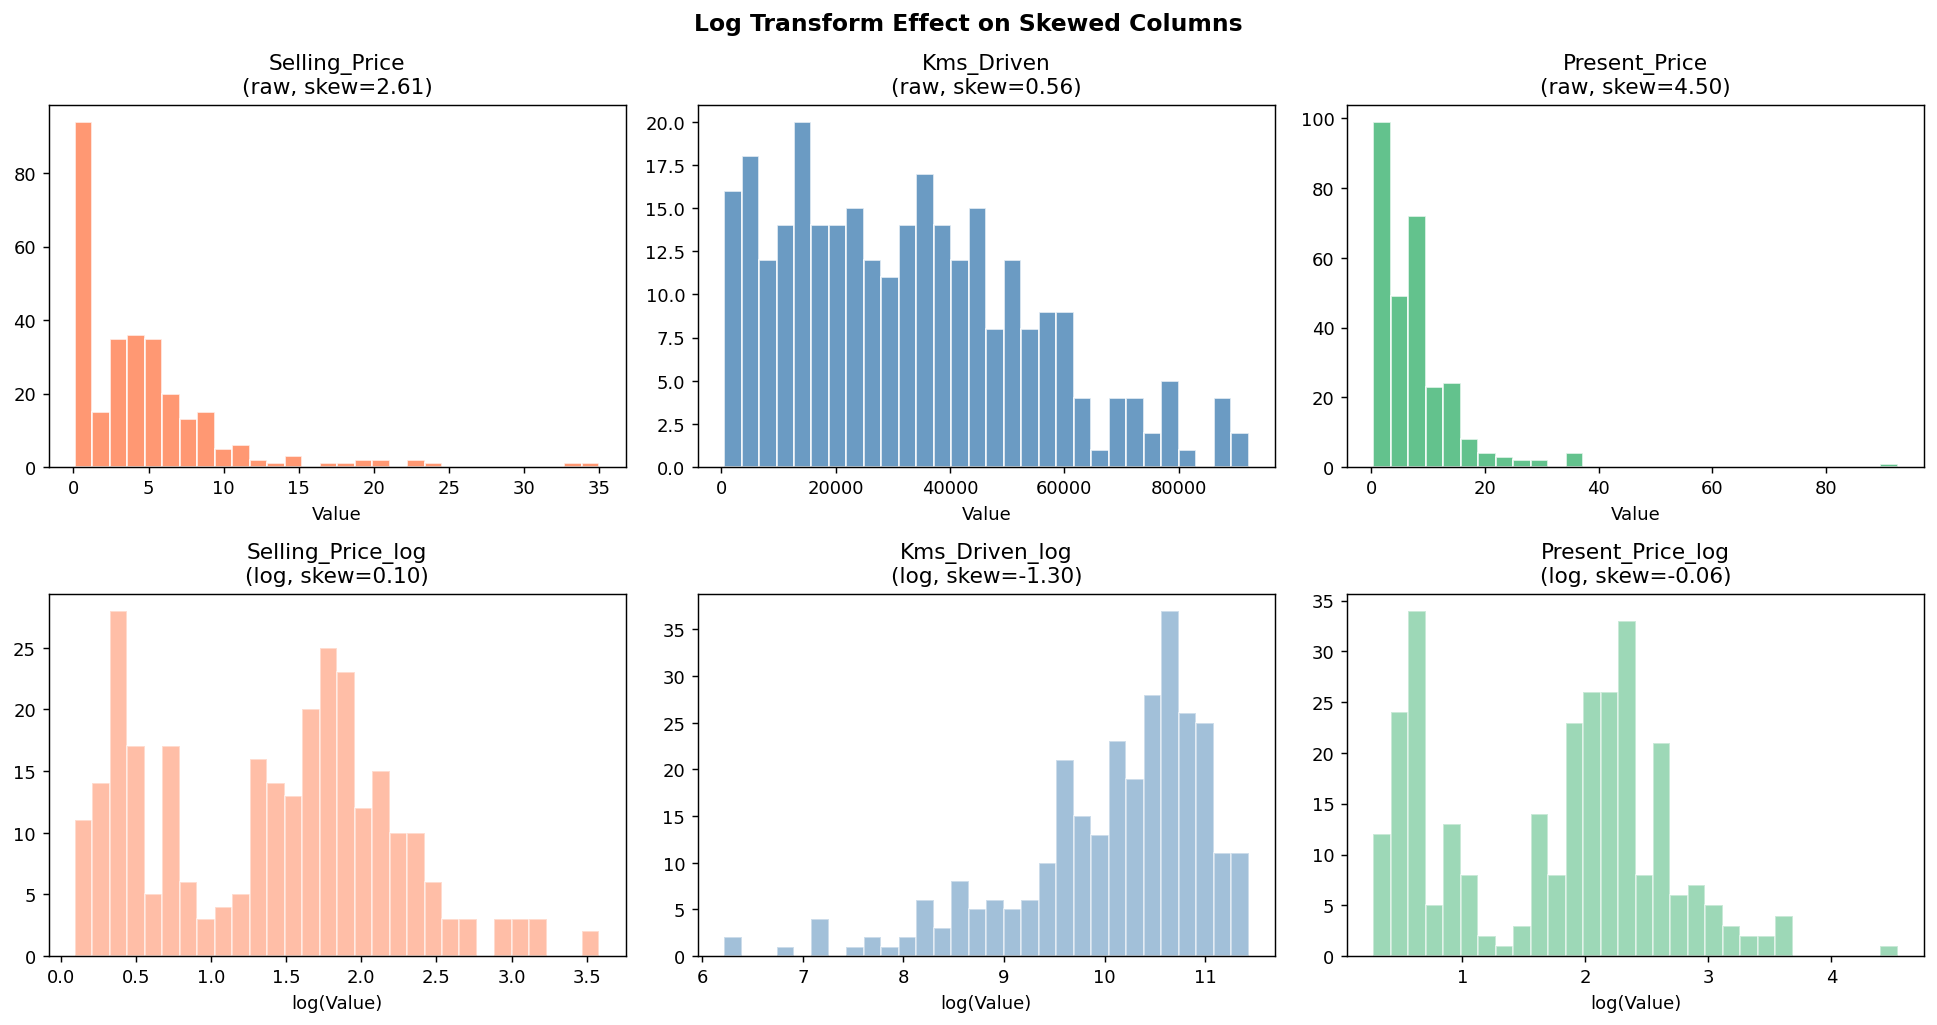

Skewness comparison:
Column                     Before      After
--------------------------------------------
Selling_Price              +2.606     +0.097
Kms_Driven                 +0.564     -1.304
Present_Price              +4.500     -0.057


In [3]:
# ============================================================
# LOG TRANSFORM
# ============================================================
# WHY LOG TRANSFORM?
#
# Imagine you're trying to predict prices that range from ₹1L to ₹35L.
# An error of ₹2L on a ₹3L car is HUGE (67% error).
# An error of ₹2L on a ₹30L car is small (7% error).
#
# Log transform compresses the scale so that:
# - Differences between cheap cars get more weight
# - Extreme expensive cars don't dominate training
# - The distribution becomes bell-shaped (better for many models)
#
# np.log1p(x) = log(x + 1)
# We use log1p instead of log to safely handle zero values.

df_fe = df.copy()   

# --- Apply log transform to skewed columns ---
df_fe['Selling_Price_log']  = np.log1p(df_fe['Selling_Price'])
df_fe['Kms_Driven_log']     = np.log1p(df_fe['Kms_Driven'])
df_fe['Present_Price_log']  = np.log1p(df_fe['Present_Price'])

# --- Visualise the effect ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Log Transform Effect on Skewed Columns',
             fontsize=13, fontweight='bold')

pairs = [
    ('Selling_Price',  'Selling_Price_log',  'coral'),
    ('Kms_Driven',     'Kms_Driven_log',     'steelblue'),
    ('Present_Price',  'Present_Price_log',  'mediumseagreen'),
]

for i, (raw_col, log_col, color) in enumerate(pairs):
    # Raw distribution
    axes[0, i].hist(df_fe[raw_col], bins=30,
                    color=color, edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{raw_col}\n(raw, skew={df_fe[raw_col].skew():.2f})')
    axes[0, i].set_xlabel('Value')

    # Log distribution
    axes[1, i].hist(df_fe[log_col], bins=30,
                    color=color, edgecolor='white', alpha=0.5)
    axes[1, i].set_title(f'{log_col}\n(log, skew={df_fe[log_col].skew():.2f})')
    axes[1, i].set_xlabel('log(Value)')

plt.tight_layout()
plt.savefig('../data/processed/fe_01_log_transforms.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Skewness comparison:")
print(f"{'Column':<22} {'Before':>10} {'After':>10}")
print("-" * 44)
for raw_col, log_col, _ in pairs:
    before = df_fe[raw_col].skew()
    after  = df_fe[log_col].skew()
    print(f"{raw_col:<22} {before:>+10.3f} {after:>+10.3f}")

In [4]:
# ============================================================
# TRANSFORMATION 2: LABEL ENCODING
# ============================================================
# WHY LABEL ENCODING?
# For columns with exactly 2 categories (binary), we simply
# convert them to 0 and 1.
#
# Seller_Type:  Dealer=1,  Individual=0
# Transmission: Manual=1,  Automatic=0

# This is called the "dummy variable trap" — a classic mistake!

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode Seller_Type
df_fe['Seller_Type_enc'] = le.fit_transform(df_fe['Seller_Type'])
print("Seller_Type encoding:")
for original, encoded in zip(
    df_fe['Seller_Type'].unique(),
    le.transform(df_fe['Seller_Type'].unique())
):
    print(f"  '{original}' → {encoded}")

# Encode Transmission
df_fe['Transmission_enc'] = le.fit_transform(df_fe['Transmission'])
print("\nTransmission encoding:")
for original, encoded in zip(
    df_fe['Transmission'].unique(),
    le.transform(df_fe['Transmission'].unique())
):
    print(f"  '{original}' → {encoded}")

# Verify
print("\nSample rows — original vs encoded:")
print(df_fe[['Seller_Type','Seller_Type_enc',
             'Transmission','Transmission_enc']].head(6))

Seller_Type encoding:
  'Dealer' → 0
  'Individual' → 1

Transmission encoding:
  'Manual' → 1
  'Automatic' → 0

Sample rows — original vs encoded:
  Seller_Type  Seller_Type_enc Transmission  Transmission_enc
0      Dealer                0       Manual                 1
1      Dealer                0       Manual                 1
2      Dealer                0       Manual                 1
3      Dealer                0       Manual                 1
4      Dealer                0       Manual                 1
5      Dealer                0       Manual                 1


In [5]:
# ============================================================
# TRANSFORMATION 3: ONE-HOT ENCODING
# ============================================================
# WHY ONE-HOT ENCODING?
# Fuel_Type has 3 categories: Petrol, Diesel, CNG
#
# We CANNOT just encode them as 0, 1, 2 because that implies
# a mathematical order: CNG(2) > Diesel(1) > Petrol(0)
# But there is no such ordering! Petrol is not "less than" Diesel.
#
# One-hot encoding creates a separate 0/1 column for each category:
#   Fuel_Type_Diesel: 1 if Diesel, else 0
#   Fuel_Type_Petrol: 1 if Petrol, else 0
#   (we DROP one category to avoid the dummy variable trap)
#
# drop_first=True drops the first category (CNG in this case).
# The model infers CNG when both Diesel and Petrol are 0.

fuel_dummies = pd.get_dummies(
    df_fe['Fuel_Type'],
    prefix='Fuel',
    drop_first=True,    # avoid dummy variable trap
    dtype=int           # ensure 0/1 integers, not True/False
)

print("One-hot encoded Fuel_Type:")
print(fuel_dummies.head(8))
print(f"\nNew columns created: {list(fuel_dummies.columns)}")
print(f"\nValue counts:")
print(fuel_dummies.sum())

# Add to dataframe
df_fe = pd.concat([df_fe, fuel_dummies], axis=1)

One-hot encoded Fuel_Type:
   Fuel_Diesel  Fuel_Petrol
0            0            1
1            1            0
2            0            1
3            0            1
4            1            0
5            1            0
6            0            1
7            1            0

New columns created: ['Fuel_Diesel', 'Fuel_Petrol']

Value counts:
Fuel_Diesel     55
Fuel_Petrol    234
dtype: int64


In [6]:
# ============================================================
# BUILDING THE FINAL CLEAN FEATURE MATRIX
# ============================================================
# Now we select ONLY the columns the model will use.
# We keep the log-transformed versions and drop the originals.
# We keep the encoded versions and drop the original text columns.

# Columns to keep — carefully chosen
feature_columns = [
    'Present_Price_log',    
    'Kms_Driven_log',       
    'Car_Age',              
    'Owner',                
    'Fuel_Diesel',         
    'Fuel_Petrol',          
    'Seller_Type_enc',      
    'Transmission_enc',     
]

# Target variable — use the log-transformed version
target_column = 'Selling_Price_log'

# Build X (features) and y (target)
X = df_fe[feature_columns].copy()
y = df_fe[target_column].copy()

print("=== Final Feature Matrix (X) ===")
print(f"Shape: {X.shape}")
print(f"\nFeature names:\n{list(X.columns)}")
print(f"\nFirst 5 rows:")
print(X.head())

print(f"\n=== Target Variable (y) ===")
print(f"Shape: {y.shape}")
print(f"Sample values: {y.head().values.round(3)}")
print(f"\nNote: y is log(Selling_Price). We'll reverse this with")
print(f"np.expm1(prediction) to get the actual price in Lakhs.")

=== Final Feature Matrix (X) ===
Shape: (291, 8)

Feature names:
['Present_Price_log', 'Kms_Driven_log', 'Car_Age', 'Owner', 'Fuel_Diesel', 'Fuel_Petrol', 'Seller_Type_enc', 'Transmission_enc']

First 5 rows:
   Present_Price_log  Kms_Driven_log  Car_Age  Owner  Fuel_Diesel  \
0           1.885553       10.203629       12      0            0   
1           2.355178       10.668979       13      0            1   
2           2.384165        8.839422        9      0            0   
3           1.638997        8.556606       15      0            0   
4           2.063058       10.656106       12      0            1   

   Fuel_Petrol  Seller_Type_enc  Transmission_enc  
0            1                0                 1  
1            0                0                 1  
2            1                0                 1  
3            1                0                 1  
4            0                0                 1  

=== Target Variable (y) ===
Shape: (291,)
Sample values: [1.47 

In [11]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================


print("=" * 55)
print("FINAL FEATURE MATRIX — QUALITY AUDIT")
print("=" * 55)

print(f"\n Shape:            {X.shape}")
print(f" Target shape:     {y.shape}")

print(f"\n Missing values in X:")
missing = X.isnull().sum()
if missing.sum() == 0:
    print("  None — all clear!")
else:
    print(missing[missing > 0])

print(f"\n Missing values in y: {y.isnull().sum()}")

print(f"\n Data types:")
print(X.dtypes.to_string())

print(f"\n Any infinite values: {np.isinf(X).sum().sum()}")

print(f"\n Feature value ranges:")
for col in X.columns:
    print(f"  {col:<22}: {X[col].min():.3f}  to  {X[col].max():.3f}")

print(f"\n Target (y) range: {y.min():.3f} to {y.max():.3f}")
print(f"  (in original Lakhs: ₹{np.expm1(y.min()):.2f}L"
      f" to ₹{np.expm1(y.max()):.2f}L)")

FINAL FEATURE MATRIX — QUALITY AUDIT

 Shape:            (291, 8)
 Target shape:     (291,)

 Missing values in X:
  None — all clear!

 Missing values in y: 0

 Data types:
Present_Price_log    float64
Kms_Driven_log       float64
Car_Age                int64
Owner                  int64
Fuel_Diesel            int64
Fuel_Petrol            int64
Seller_Type_enc        int64
Transmission_enc       int64

 Any infinite values: 0

 Feature value ranges:
  Present_Price_log     : 0.278  to  4.539
  Kms_Driven_log        : 6.217  to  11.432
  Car_Age               : 8.000  to  23.000
  Owner                 : 0.000  to  1.000
  Fuel_Diesel           : 0.000  to  1.000
  Fuel_Petrol           : 0.000  to  1.000
  Seller_Type_enc       : 0.000  to  1.000
  Transmission_enc      : 0.000  to  1.000

 Target (y) range: 0.095 to 3.584
  (in original Lakhs: ₹0.10L to ₹35.00L)


In [8]:
# ============================================================
# SAVEING THE  FEATURES
# ============================================================

# Combine X and y into one file for easy loading later
df_final = X.copy()
df_final['Selling_Price_log'] = y.values

# Save
df_final.to_csv('../data/processed/car_data_engineered.csv', index=False)

# Also save X and y separately for modelling notebook
X.to_csv('../data/processed/X_features.csv', index=False)
y.to_csv('../data/processed/y_target.csv', index=False)

print("Files saved:")
print("  data/processed/car_data_engineered.csv  ← full engineered dataset")
print("  data/processed/X_features.csv           ← feature matrix only")
print("  data/processed/y_target.csv             ← target column only")
print(f"\nFinal dataset shape: {df_final.shape}")
print(f"\nFeature matrix preview:")
df_final.head(3)

Files saved:
  data/processed/car_data_engineered.csv  ← full engineered dataset
  data/processed/X_features.csv           ← feature matrix only
  data/processed/y_target.csv             ← target column only

Final dataset shape: (291, 9)

Feature matrix preview:


,Present_Price_log,Kms_Driven_log,Car_Age,Owner,Fuel_Diesel,Fuel_Petrol,Seller_Type_enc,Transmission_enc,Selling_Price_log
0,1.885553,10.203629,12,0,0,1,0,1,1.470176
1,2.355178,10.668979,13,0,1,0,0,1,1.749200
2,2.384165,8.839422,9,0,0,1,0,1,2.110213


In [10]:
# ============================================================
# THE TRANSFORMATION 
# ============================================================


print("""
╔══════════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING TRANSFORMATION RECIPE            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DROPPED COLUMNS                                             ║
║  • Car_Name  — too many unique values, limited signal        ║
║  • Year      — replaced by Car_Age (more meaningful)         ║
║  • Selling_Price (raw) — replaced by log version             ║
║  • Present_Price (raw) — replaced by log version             ║
║  • Kms_Driven (raw)    — replaced by log version             ║
║  • Fuel_Type (text)    — replaced by one-hot columns         ║
║  • Seller_Type (text)  — replaced by encoded column          ║
║  • Transmission (text) — replaced by encoded column          ║
║                                                              ║
║  CREATED COLUMNS                                             ║
║  • Present_Price_log   = np.log1p(Present_Price)             ║
║  • Kms_Driven_log      = np.log1p(Kms_Driven)                ║
║  • Fuel_Diesel         = 1 if Diesel, else 0                 ║
║  • Fuel_Petrol         = 1 if Petrol, else 0                 ║
║    (CNG = Fuel_Diesel=0 AND Fuel_Petrol=0)                   ║
║  • Seller_Type_enc     = LabelEncoder (Dealer=1, Indiv=0)    ║
║  • Transmission_enc    = LabelEncoder (Manual=1, Auto=0)     ║
║                                                              ║
║  TARGET VARIABLE                                             ║
║  • y = np.log1p(Selling_Price)                               ║
║  • To reverse predictions: price = np.expm1(y_pred)          ║
║                                                              ║
║  SCALING (applied AFTER train/test split in next step)       ║
║  • StandardScaler on all numeric features                    ║
║  • Fit on X_train only, transform both X_train & X_test      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         FEATURE ENGINEERING TRANSFORMATION RECIPE            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DROPPED COLUMNS                                             ║
║  • Car_Name  — too many unique values, limited signal        ║
║  • Year      — replaced by Car_Age (more meaningful)         ║
║  • Selling_Price (raw) — replaced by log version             ║
║  • Present_Price (raw) — replaced by log version             ║
║  • Kms_Driven (raw)    — replaced by log version             ║
║  • Fuel_Type (text)    — replaced by one-hot columns         ║
║  • Seller_Type (text)  — replaced by encoded column          ║
║  • Transmission (text) — replaced by encoded column          ║
║                                                              ║
║  CREATED COLUMNS                                             ║
║  • Present_Price_log  